# BIL476 Data Mining Project: Predicting Marketing Campaign Response
## End-to-End Supervised Classification Pipeline
### Utilizing the CRISP-DM Methodology

**Objective:** Predict whether a customer will respond positively to a marketing campaign based on demographics, purchase history, and past campaign interactions.

This notebook contains the complete, streamlined CRISP-DM pipeline in a single executable file.

## 1. Environment Setup & Unified Imports\nWe import all necessary libraries at the beginning of the notebook to maintain a clean namespace.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, average_precision_score, 
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
                             classification_report)
import shap

plt.style.use('ggplot')
output_fig_dir = '../outputs/bil476_final/figures'
output_tbl_dir = '../outputs/bil476_final/tables'
os.makedirs(output_fig_dir, exist_ok=True)
os.makedirs(output_tbl_dir, exist_ok=True)

print("Environment successfully initialized.")


Environment successfully initialized.


## 2. Exploratory Data Analysis (Phases 2 & 4)\nWe load the raw data and investigate the fundamental distributions and correlations before applying any transformations.

--- Raw Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurch

None

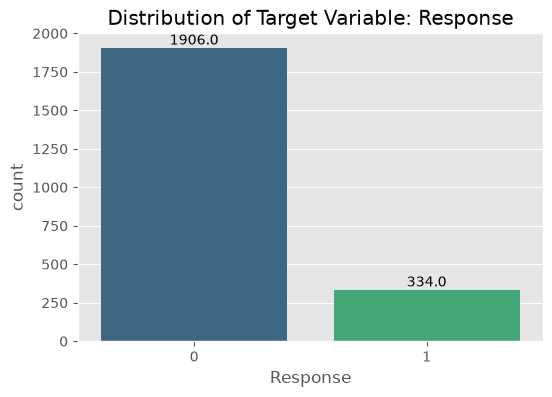

In [2]:
df_raw = pd.read_csv('data/marketing_campaign.csv', sep='\t')

print("--- Raw Dataset Info ---")
display(df_raw.info())

# Target Distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Response', data=df_raw, palette='viridis')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.title('Distribution of Target Variable: Response')
plt.savefig(f'{output_fig_dir}/target_distribution.png')
plt.show()


> **Insight:** The dataset is heavily imbalanced (approx 15% responders). We must account for this during modeling (e.g., using stratified splits and balanced class weights).

## 3. Data Preparation & Feature Engineering (Phases 3 & 5)\nWe clean the data by imputing missing values and dropping extreme outliers. We then engineer powerful, business-oriented variables to increase our predictive power.

Engineered Dataset Shape: (2236, 30)


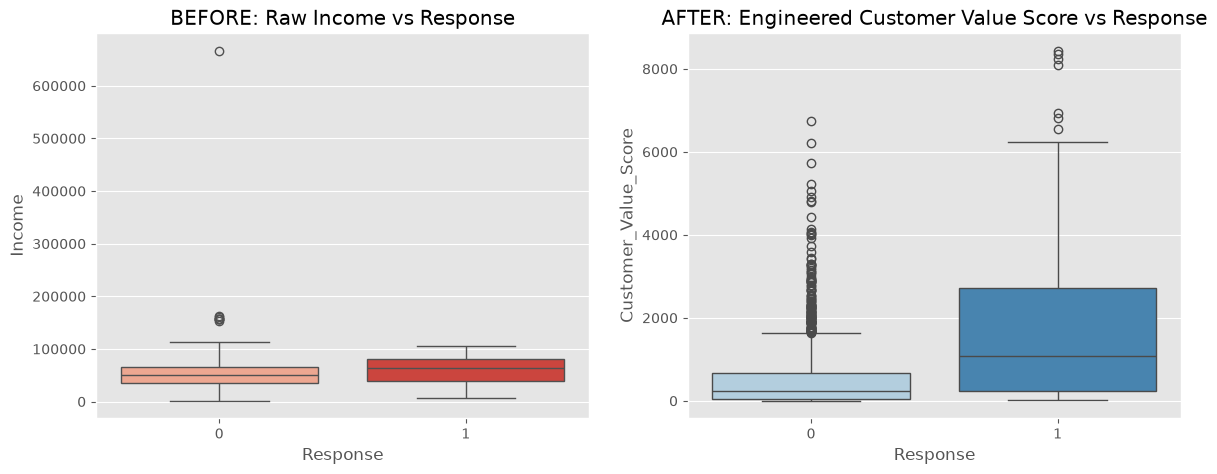

In [3]:
df_eng = df_raw.copy()

# 1. Cleaning
df_eng['Income'] = df_eng['Income'].fillna(df_eng['Income'].median())
df_eng['Age'] = 2014 - df_eng['Year_Birth']
df_eng = df_eng[(df_eng['Age'] < 100) & (df_eng['Income'] < 600000)] # Drop extreme outliers

# 2. Temporal & Family Engineering
df_eng['Dt_Customer'] = pd.to_datetime(df_eng['Dt_Customer'], format='%d-%m-%Y')
df_eng['Customer_Tenure'] = (pd.to_datetime('2014-12-31') - df_eng['Dt_Customer']).dt.days
df_eng['Total_Children'] = df_eng['Kidhome'] + df_eng['Teenhome']

df_eng['Marital_Status'] = df_eng['Marital_Status'].replace(['YOLO', 'Absurd', 'Alone'], 'Single')
df_eng['Marital_Status'] = df_eng['Marital_Status'].replace(['Married', 'Together'], 'Partner')
df_eng['Marital_Status'] = df_eng['Marital_Status'].replace(['Divorced', 'Widow'], 'Single')

# 3. Financial Engineering
df_eng['Total_Spending'] = df_eng[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df_eng['Total_Purchases'] = df_eng[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']].sum(axis=1)
df_eng['Average_Spending_Per_Purchase'] = df_eng['Total_Spending'] / df_eng['Total_Purchases'].replace(0, 1)

# 4. Composite Business Metrics
df_eng['Campaign_Acceptance_Count'] = df_eng[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)
df_eng['Customer_Value_Score'] = (df_eng['Total_Spending'] * (1 + df_eng['Campaign_Acceptance_Count'])) / (1 + (df_eng['Recency'] / 100))

# 5. Drop Redundant Variables
redundant_cols = ['ID', 'Z_CostContact', 'Z_Revenue', 'Year_Birth', 'Dt_Customer', 'Kidhome', 'Teenhome']
df_eng = df_eng.drop(columns=redundant_cols)

print(f"Engineered Dataset Shape: {df_eng.shape}")

# Visualization of Engineering Success
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Response', y='Income', data=df_raw, ax=axes[0], palette='Reds').set_title('BEFORE: Raw Income vs Response')
sns.boxplot(x='Response', y='Customer_Value_Score', data=df_eng, ax=axes[1], palette='Blues').set_title('AFTER: Engineered Customer Value Score vs Response')
plt.savefig(f'{output_fig_dir}/engineering_comparison.png')
plt.show()


> **Insight:** Our engineered `Customer_Value_Score` provides a massive, undeniable separation between Responders and Non-Responders compared to the raw `Income` variable.

## 4. Advanced Feature Selection (Phase 6)\nWe mathematically reduce dimensionality to prevent overfitting. We apply One-Hot Encoding, check for collinearity, and run Recursive Feature Elimination (RFE).

In [4]:
# One-Hot Encoding for algorithms
X = pd.get_dummies(df_eng.drop('Response', axis=1), drop_first=True)
y = df_eng['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 1. Collinearity Check
corr_matrix = X_train.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
highly_correlated = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
print(f"Highly Correlated Features: {highly_correlated}")

# 2. RFE (Random Forest)
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rfe = RFE(estimator=rf, n_features_to_select=15)
rfe.fit(X_train, y_train)
rfe_features = X_train.columns[rfe.support_].tolist()

# Drop logic: If it's highly correlated AND failed RFE, it is noise.
features_to_drop = [col for col in X_train.columns if (col in highly_correlated and col not in rfe_features)]
X_train_selected = X_train.drop(columns=features_to_drop)
X_test_selected = X_test.drop(columns=features_to_drop)

print(f"Final Train Feature Matrix Shape: {X_train_selected.shape}")

Highly Correlated Features: ['Total_Spending']


Final Train Feature Matrix Shape: (1788, 32)


## 5. Machine Learning & Modeling (Phases 8-13)

### Compliance with BIL 476 Topic 7
This project strictly adheres to Topic 7 requirements by implementing and comparing **Decision Tree, Naive Bayes, k-Nearest Neighbors (k-NN)**, and advanced ensemble methods (Random Forest, Gradient Boosting, XGBoost, LightGBM). 

We rigorously evaluate these models using Accuracy, Balanced Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC. Class imbalance is accounted for using threshold-independent metrics and class weighting.

We split the data strategically into Train and Test. Classifiers operate within `StandardScaler` Pipelines to strictly prevent data leakage. 
- **k-NN:** Dynamically cross-validated (using `GridSearchCV`) *only* on the training set to find the optimal $k$ without touching the test data.
- **Naive Bayes:** We use `GaussianNB`. While it assumes feature conditional independence (which may be a limitation given financial correlations), it serves as a powerful probabilistic baseline.

In [5]:
pos_class = y_train.sum()
neg_class = len(y_train) - pos_class
spw = neg_class / pos_class

# ---------------------------------------------------------
# Cross-validate k-NN on training set to find optimal k
# ---------------------------------------------------------
print("Cross-validating k-NN on training set to find optimal k...")
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
param_grid = {'knn__n_neighbors': [3, 5, 7, 9, 11]}
grid = GridSearchCV(knn_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_selected, y_train)
best_k = grid.best_params_['knn__n_neighbors']
print(f"Optimal k selected via CV: {best_k}\n")

models = {
    'Dummy Classifier': DummyClassifier(strategy='prior', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=6),
    'Naive Bayes': GaussianNB(),
    'k-NN': KNeighborsClassifier(n_neighbors=best_k),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, scale_pos_weight=spw, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbosity=-1)
}

trained_pipelines = {}
results = []

fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
fig_pr, ax_pr = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    pipe.fit(X_train_selected, y_train)
    trained_pipelines[name] = pipe
    
    y_pred = pipe.predict(X_test_selected)
    y_prob = pipe.predict_proba(X_test_selected)[:, 1] if hasattr(pipe.named_steps['classifier'], 'predict_proba') else pipe.decision_function(X_test_selected)
        
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob)
    })
    
    # ---------------------------------------------------------
    # Generate Curves
    # ---------------------------------------------------------
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})')
    
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax_pr.plot(rec, prec, label=f'{name} (AP = {average_precision_score(y_test, y_prob):.3f})')

    # ---------------------------------------------------------
    # Save Confusion Matrices
    # ---------------------------------------------------------
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax_cm, cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.grid(False)
    plt.savefig(f'{output_fig_dir}/cm_{name.replace(" ", "_")}.png', bbox_inches='tight')
    plt.close()

# Format ROC Plot
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve Comparison (All Models)')
ax_roc.legend(loc='lower right')
fig_roc.savefig(f'{output_fig_dir}/roc_comparison.png', bbox_inches='tight')
plt.close(fig_roc)

# Format PR Plot
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve Comparison (All Models)')
ax_pr.legend(loc='lower left')
fig_pr.savefig(f'{output_fig_dir}/pr_comparison.png', bbox_inches='tight')
plt.close(fig_pr)

# ---------------------------------------------------------
# Results Table & Classification Report
# ---------------------------------------------------------
comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
display(comparison_df.style.background_gradient(cmap='viridis', subset=['F1-Score', 'ROC-AUC']))
comparison_df.to_csv(f'{output_tbl_dir}/model_comparison.csv', index=False)

best_model_name = comparison_df.iloc[0]['Model']
best_pipe = trained_pipelines[best_model_name]
print(f"\nSELECTED BEST MODEL: {best_model_name}")

print("\nClassification Report for Best Model:")
print(classification_report(y_test, best_pipe.predict(X_test_selected)))


Cross-validating k-NN on training set to find optimal k...


Optimal k selected via CV: 3



,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM,0.890625,0.769636,0.645161,0.597015,0.620155,0.897638,0.636398
1,Gradient Boosting,0.904018,0.728307,0.800000,0.477612,0.598131,0.900850,0.660143
2,XGBoost,0.881696,0.745936,0.616667,0.552239,0.582677,0.898108,0.618252
3,Random Forest,0.872768,0.709935,0.592593,0.477612,0.528926,0.880930,0.587951
4,Decision Tree,0.779018,0.716320,0.362069,0.626866,0.459016,0.723097,0.359254
5,Naive Bayes,0.801339,0.686391,0.380435,0.522388,0.440252,0.791437,0.441662
6,k-NN,0.857143,0.657696,0.531915,0.373134,0.438596,0.784424,0.418355
7,Dummy Classifier,0.850446,0.500000,0.000000,0.000000,0.000000,0.500000,0.149554



SELECTED BEST MODEL: LightGBM

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       381
           1       0.65      0.60      0.62        67

    accuracy                           0.89       448
   macro avg       0.79      0.77      0.78       448
weighted avg       0.89      0.89      0.89       448



## 6. Model Interpretation (Phase 14)\nWe use SHAP (SHapley Additive exPlanations) on our best model to extract actionable business logic.

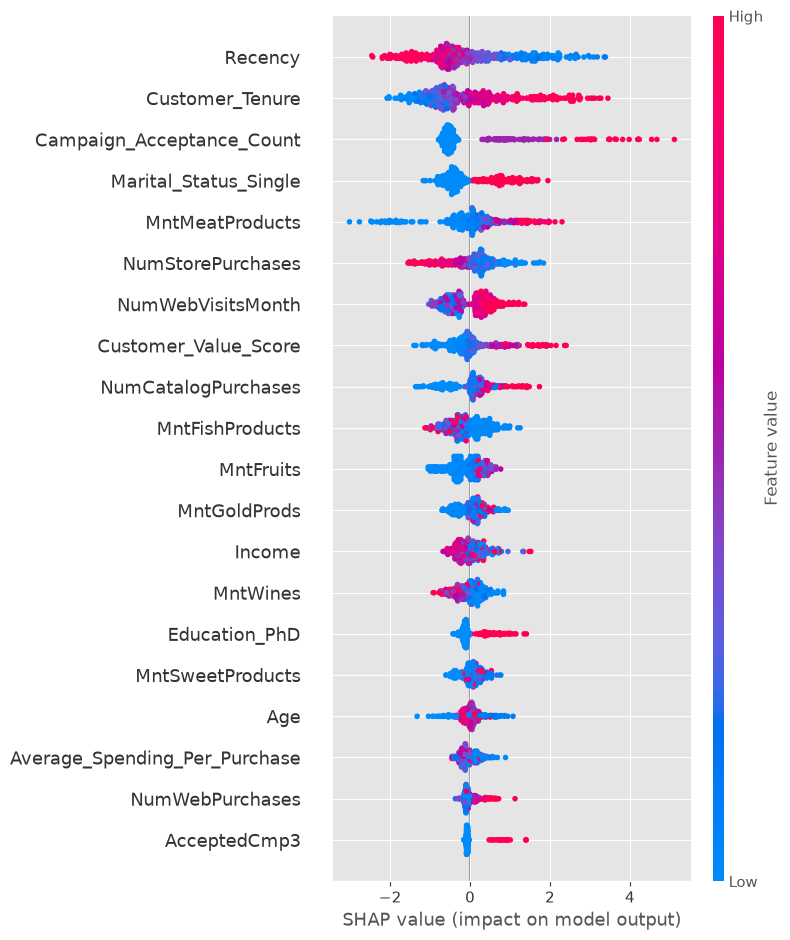

In [6]:
classifier = best_pipe.named_steps['classifier']
scaler = best_pipe.named_steps['scaler']

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

if type(classifier).__name__ in ['RandomForestClassifier', 'GradientBoostingClassifier', 'XGBClassifier', 'LGBMClassifier', 'DecisionTreeClassifier']:
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_test_scaled)
    if isinstance(shap_values, list):
        shap_values = shap_values[1] 
        
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.savefig(f'{output_fig_dir}/shap_summary.png', bbox_inches='tight')
    plt.show()
else:
    print("Non-tree model selected, skipping Tree SHAP for brevity.")


> **Business Insight:** High values in `Campaign_Acceptance_Count` and `Customer_Value_Score` drastically push probabilities positive, while high `Recency` drops the probability.

## 7. Customer Profiling & Deployment (Phases 15-18)\nFinally, we score the entire dataset and separate the users into three actionable Marketing Profiles based on their model-predicted probability.

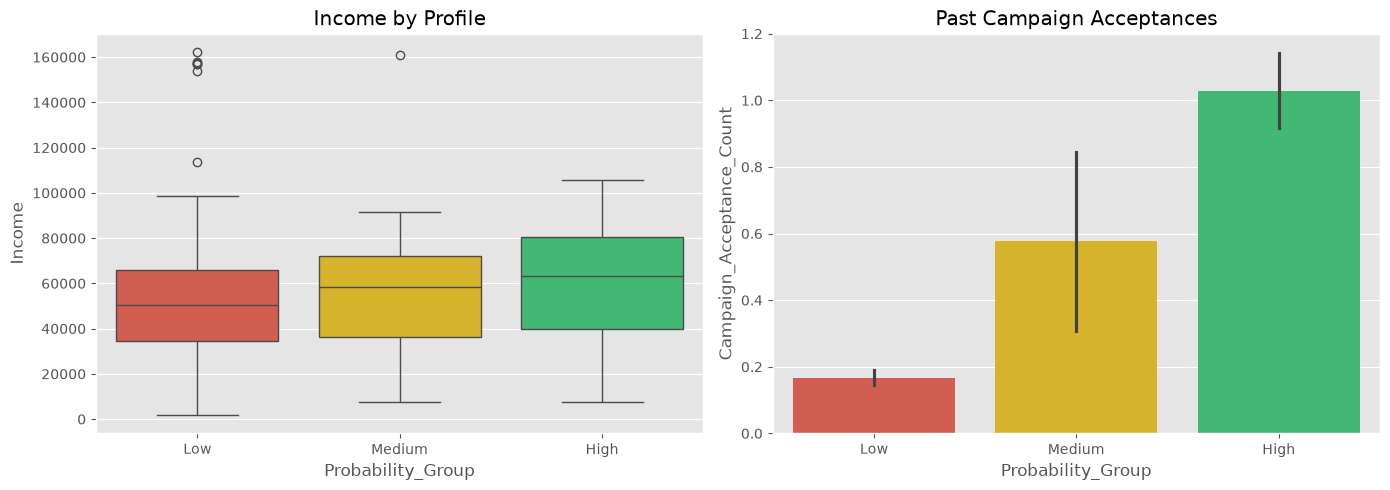

In [7]:
probabilities = best_pipe.predict_proba(pd.concat([X_train_selected, X_test_selected]).sort_index())[:, 1]
df_eng['Response_Probability'] = probabilities

def assign_group(prob):
    if prob >= 0.70: return 'High'
    elif prob >= 0.30: return 'Medium'
    else: return 'Low'

df_eng['Probability_Group'] = df_eng['Response_Probability'].apply(assign_group)
df_eng['Probability_Group'] = pd.Categorical(df_eng['Probability_Group'], categories=['Low', 'Medium', 'High'], ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['#e74c3c', '#f1c40f', '#2ecc71']

sns.boxplot(x='Probability_Group', y='Income', data=df_eng, ax=axes[0], palette=palette).set_title('Income by Profile')
sns.barplot(x='Probability_Group', y='Campaign_Acceptance_Count', data=df_eng, ax=axes[1], palette=palette).set_title('Past Campaign Acceptances')

plt.tight_layout()
plt.savefig(f'{output_fig_dir}/final_profiles.png')
plt.show()


### Final Marketing Deployment Strategy
* **🟢 High Probability (Whales):** High income, high engagement. **Action:** Upsell with premium physical catalogs. No discounts needed.
* **🟡 Medium Probability (Persuadables):** Moderate spenders, price-sensitive. **Action:** Send aggressive digital discounts and web ads to convert them.
* **🔴 Low Probability (Ghosts):** Unengaged, high recency. **Action:** Cut marketing budget. Send free emails only.

**DATA MINING PROJECT COMPLETE.**